<a href="https://colab.research.google.com/github/Raju-mia-RK/Raju/blob/colab_work/RandomRorest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df=pd.read_csv('/content/drive/MyDrive/datasets/diabetes.csv')

In [7]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,recall_score,accuracy_score,f1_score
from imblearn.over_sampling import RandomOverSampler

In [11]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']


In [12]:
ov=RandomOverSampler()
x,y=ov.fit_resample(x,y)

In [13]:
y.value_counts()

,count
Outcome,
1,500
0,500


In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [16]:
random=RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    min_samples_leaf=20,
    min_samples_split=20,
    n_jobs=1
)

In [17]:
random.fit(x_train,y_train)

RandomForestClassifier(min_samples_leaf=20, min_samples_split=20, n_jobs=1)

In [18]:
random.score(x_test,y_test)

0.785

In [19]:
print(f"Accuracy score: {accuracy_score(y_test,random.predict(x_test))}")

Accuracy score: 0.785


<Axes: >

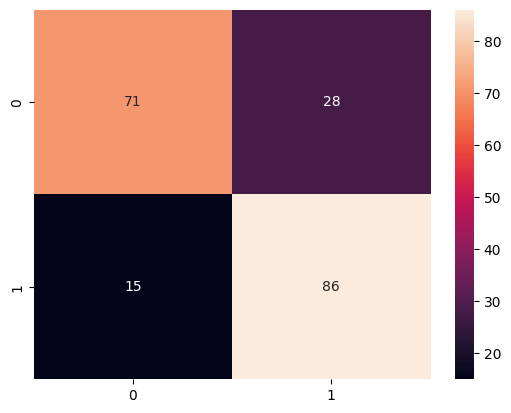

In [20]:
cm=confusion_matrix(y_test,random.predict(x_test))
sns.heatmap(cm,annot=True)

In [25]:
importance_feature=pd.DataFrame({
    'Feature':x.columns,
    'Importance':random.feature_importances_
}).sort_values('Importance',ascending=False)
print(importance_feature.to_string(index=False))

                 Feature  Importance
                 Glucose    0.373289
                     Age    0.193277
                     BMI    0.184326
             Pregnancies    0.061920
                 Insulin    0.060839
DiabetesPedigreeFunction    0.055264
           SkinThickness    0.046747
           BloodPressure    0.024339


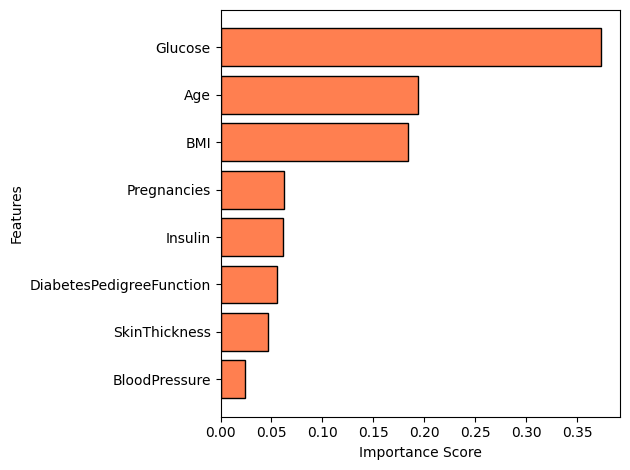

In [32]:
plt.barh(importance_feature['Feature'],importance_feature['Importance'],color='coral',edgecolor='black')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.tight_layout()